In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.2)

In [20]:
df = pd.read_csv("flats_moscow.csv")

In [36]:
df = df.drop(columns=["Unnamed: 0"])

In [37]:
numeric_cols = [
    "price", "total_area", "living_area", "kitchen_area",
    "distance_to_metro", "metrdist", "floor"
]

In [38]:
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

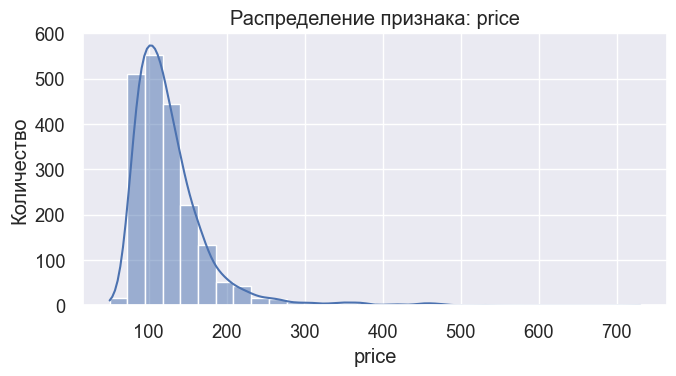

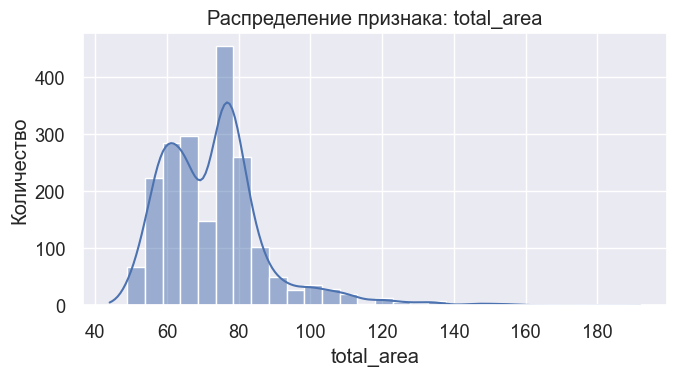

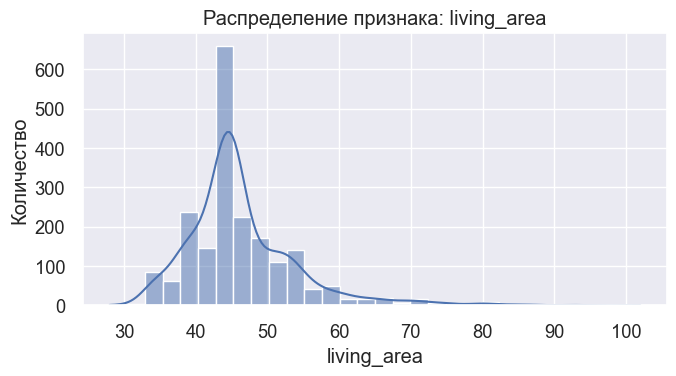

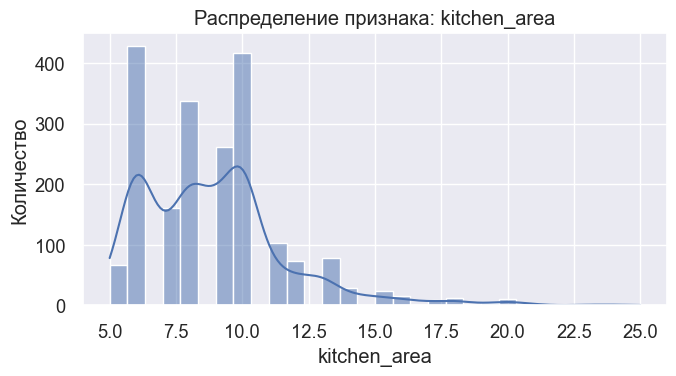

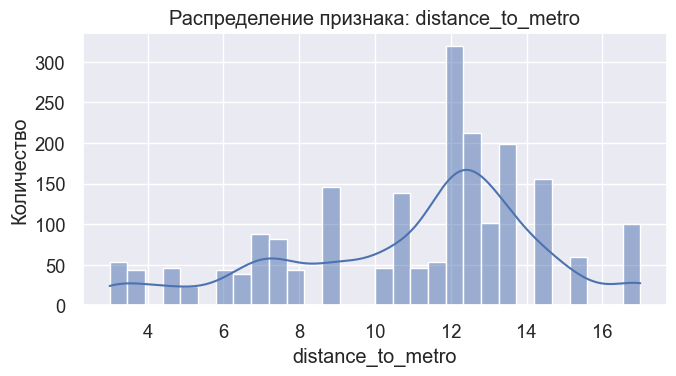

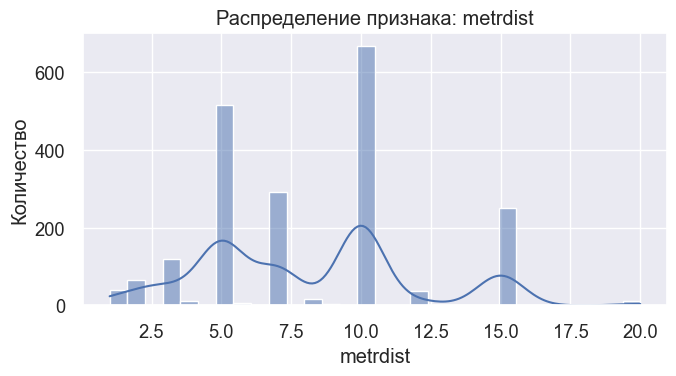

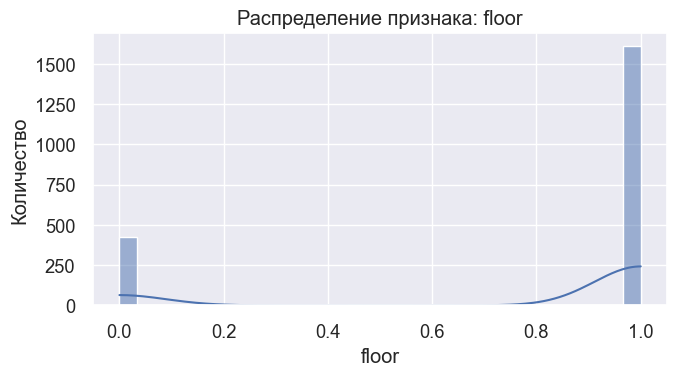

In [43]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

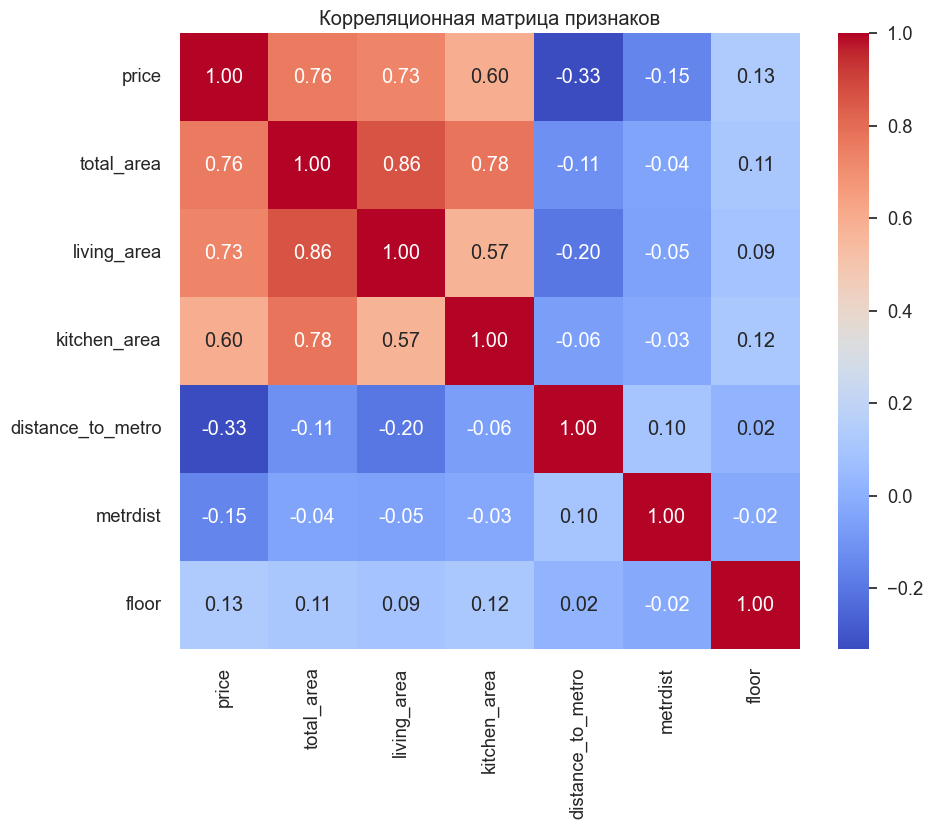

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица признаков")
plt.show()

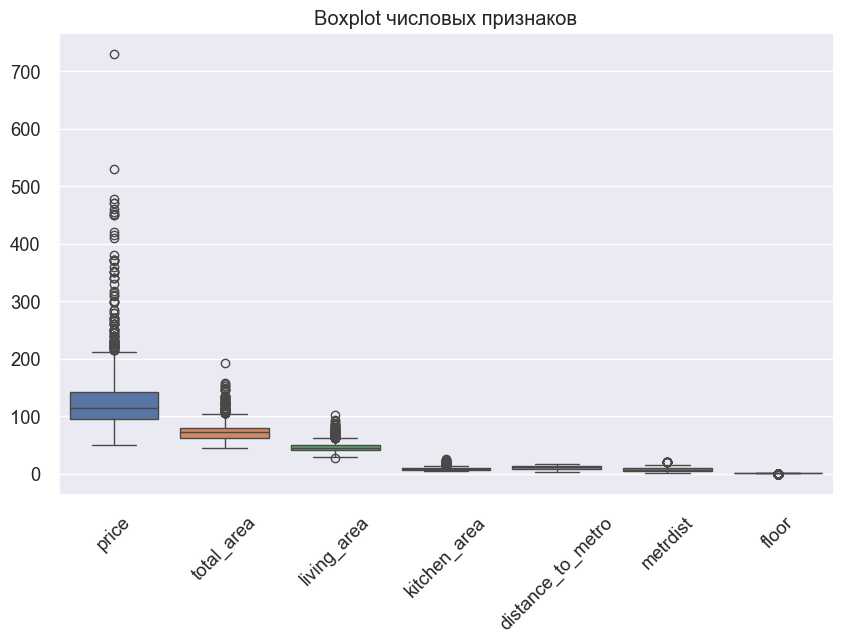

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot числовых признаков")
plt.xticks(rotation=45)
plt.show()

In [41]:
df_metro = df[df["walk_access"] == 1]
df_big = df[df["total_area"] > 80]
df_cheap = df[df["price"] < 6_000_000]

In [42]:
grouped = df.groupby(["district", "walk_access"])["price"].agg(["mean", "count"])
print(grouped)

                            mean  count
district walk_access                   
1        0            112.250000     68
         1            141.799020    204
2        0            104.404762     42
         1            111.751445    173
3        0            120.794872    156
         1            170.904762    189
4        0            154.196721     61
         1            146.425676    148
5        0            105.024096     83
         1            119.308300    253
6        0            109.445652     92
         1            110.254545    165
7        0            106.646465     99
         1            120.141732    127
8        0            116.200000     40
         1            142.614286    140


In [ ]:
df_encoded = pd.get_dummies(df_filtered, columns=cat_cols, drop_first=True)

df_encoded.head()

In [ ]:
df_encoded["price_per_m2"] = df_encoded["price"] / df_encoded["totsp"]
df_encoded["is_near_metro"] = (df_encoded["dist"] < df_encoded["dist"].median()).astype(int)

df_encoded[["price", "totsp", "price_per_m2", "dist", "is_near_metro"]].head()

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df_encoded["price_per_m2"], bins=30, kde=True)
plt.title("Распределение цены за м²")
plt.show()

In [ ]:
df_encoded.to_csv("flats_moscow_processed.csv")

In [35]:
df.columns

Index(['Unnamed: 0', 'price', 'total_area', 'living_area', 'kitchen_area',
       'distance_to_metro', 'metrdist', 'walk_access', 'brick', 'floor',
       'district'],
      dtype='str')